In [2]:
import nltk
import pandas as pd
import os
from glob import iglob

#print("test")

data = {
    'review_ID': [],
    'truth_value': [],
    'text': [],
    'hotel_review_length': []
}

review_df = pd.DataFrame(data)
data_file_path = 'review_data.csv'

id = 0

# Generating data items / fetching text
def addData(givenDir, truthVal):
    global id
    # Source - https://stackoverflow.com/a - Found way to iterate through files with iglob
    # Posted by joelostblom, modified by community.
    rootdir_glob = givenDir + '/**/*'
    file_list = [f for f in iglob(rootdir_glob, recursive=True) if os.path.isfile(f)]
    for f in file_list:
        # print(f)
    # End of sourced code
        currFile = os.open(f, os.O_RDONLY)
        fileSize = os.stat(currFile).st_size
        text = os.read(currFile, fileSize)
        textLen = len(text)
        review_df.loc[id] = {'review_ID': id, 'truth_value': truthVal, 'text': text, 'hotel_review_length': textLen}
        
        os.close(currFile)
        id += 1

# Getting negative polarity deceptive reviews
addData("./negative_polarity/deceptive_from_MTurk", False)
# Getting negative polarity truthful reviews
addData("./negative_polarity/truthful_from_Web", True)
# Getting positive polarity deceptive reviews
addData("./positive_polarity/deceptive_from_MTurk", False)
# Getting positive polarity truthful reviews
addData("./positive_polarity/truthful_from_Web", True)

# Write the dataframe to the csv file
review_df.to_csv(data_file_path, index=False)

print("Showcase of ID and Hotel Review Length")
print("First Five Items:")
for i in range(5):
    user_id = review_df.iloc[i]['review_ID']
    corr_length = review_df.iloc[i]['hotel_review_length']
    print(i+1, ") ", user_id, " ", corr_length)


Showcase of ID and Hotel Review Length
First Five Items:
1 )  0   1508
2 )  1   446
3 )  2   1020
4 )  3   820
5 )  4   1084


In [3]:
# Task 4 - Remove Stop Words
import nltk
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nostop_file_path = "data_without_stop.csv"
nostop_df = pd.read_csv("review_data.csv")

def remove_stopwords(text):
    words = word_tokenize(text)
    tokenized_no_stopwords_corpus = [word for word in words if word not in stop_words]
    return " ".join(tokenized_no_stopwords_corpus)

# Thank you https://www.geeksforgeeks.org/pandas/pandas-functions-in-python/ for the apply function
nostop_df["text"] = nostop_df["text"].apply(remove_stopwords)

nostop_df.to_csv(nostop_file_path, index=False)
print("Stop-word removal successful!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kelly\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kelly\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kelly\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stop-word removal successful!


In [4]:
# Task 5 - Remove Numbers
import re

nonum_file_path = "new_without_numbers.csv"
nonum_df = pd.read_csv("data_without_stop.csv")


# Source - https://stackoverflow.com/questions/57030670/how-to-remove-punctuation-and-numbers-during-tweettokenizer-step-in-nlp
# Posted by Anubhav Singh, modified by community. See post 'Timeline' for change history
def remove_numbers(text):
    text_nonum = re.sub(r'\d+', '', str(text))
    return text_nonum
# End of referenced code - specifically the "re.sub(r'\d+', '', text)"

nonum_df["text"] = nonum_df["text"].apply(remove_numbers)

nonum_df.to_csv(nonum_file_path, index=False)
print("Number removal successful!")

Number removal successful!


In [5]:
# Task 6 Lemmaization
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

df = pd.read_csv("new_without_numbers.csv")

def lemmatize_words(text):
    tokens = word_tokenize(text)
    lemmatized_corpus = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_corpus)

df["text"] = df["text"].apply(lemmatize_words)
df.to_csv("new_without_numbers.csv", index=False)
print("Lemmaized!")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kelly\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Lemmaized!


In [6]:
# Task 7 TF-IDF vectorization to convert it into a numerical vector.
# 'it'??? What's it? I understand this is to basically find the values for the next task so I'm going to focus on accomplishing that
# - Also Task 8: Identify 10 most common words in the dataset
import csv
# Used https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/
# pip install scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

filename = "new_without_numbers.csv"
corpus = []

with open(filename, 'r') as csvfile:
    csvreader = csv.reader(csvfile)
    next(csvreader)

    for line in csvreader:
        corpus.append(line[2])

tfidf = TfidfVectorizer()
result = tfidf.fit_transform(corpus)

# Source - https://stackoverflow.com/questions/45805493/sorting-tfidfvectorizer-output-by-tf-idf-lowest-to-highest-and-vice-versa
# Posted by Adelson Araújo, modified by community. See post 'Timeline' for change history
# Used to work with tfidf

terms = tfidf.get_feature_names_out()
sums = result.sum(axis=0)

# connecting term to its sums frequency
freqData = []
for col, term in enumerate(terms):
    freqData.append( (term, sums[0,col] ))

ranking = pd.DataFrame(freqData, columns=['term','rank'])
ranking = ranking.sort_values('rank', ascending=False)
# End of reference
# I recognize that something went wrong with lemmaization(?)
print(ranking.head(10))

         term       rank
3269    hotel  82.156016
5675     room  77.296891
6791      the  74.300870
1130  chicago  47.821798
6419     stay  42.393209
7466       we  37.370484
5936  service  34.214327
7617    would  34.150898
6376    staff  31.710079
2968    great  30.684935


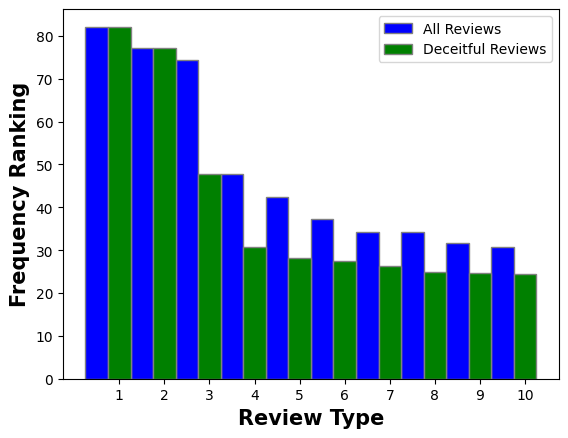

In [7]:
# Task 9 Create a plot that represents the frequency of top 10 words vs a top 10 words in both truthful reviews and deceptive reviews
# I'm going to assume you mean 'Create a plot that represents the frequency of the top 10 words in deceptive reviews VS top 10 in truth + deceptive'

# Reviewed how plotting works at https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/
import matplotlib.pyplot as plt
import numpy as np

# Doing task 7/8 again just for the deceiptful reveiews
filename = "new_without_numbers.csv"
deceit_corpus = []
with open(filename, 'r') as csvfile:
    csvreader = csv.reader(csvfile)
    next(csvreader)

    for line in csvreader:
        if line[1] == "False":
            deceit_corpus.append(line[2])

deceit_tfidf = TfidfVectorizer()
deceit_result = deceit_tfidf.fit_transform(deceit_corpus)

deceit_terms = deceit_tfidf.get_feature_names_out()
deceit_sums = result.sum(axis=0)

# connecting term to its sums frequency
deceit_freqData = []
for col, term in enumerate(deceit_terms):
    deceit_freqData.append( (deceit_terms, deceit_sums[0,col] ))

deceit_ranking = pd.DataFrame(deceit_freqData, columns=['term','rank'])
deceit_ranking = deceit_ranking.sort_values('rank', ascending=False)

## Fetching info
all_rev = []
deceit_rev = []
for i in range(10):
    all_rev.append(ranking.iloc[i]["rank"])
    deceit_rev.append(deceit_ranking.iloc[i]["rank"])

# Plotting Stuff
barWidth = 0.5
br1 = np.arange(len(all_rev)) 
br2 = [x + barWidth for x in br1]

plt.bar(br1, all_rev, color ='b', width = barWidth, 
        edgecolor ='grey', label ='All Reviews') 
plt.bar(br2, deceit_rev, color ='g', width = barWidth, 
        edgecolor ='grey', label ='Deceitful Reviews') 

plt.xlabel('Review Type', fontweight ='bold', fontsize = 15) 
plt.ylabel('Frequency Ranking', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth for r in range(len(all_rev))], 
        ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])

plt.legend()
plt.show() 

### a. Briefly explain what you observe from the plot that you obtained from Task 9.
While the two most frequent words are the same, it's clear that the most frequent words in deceitful reviews are closer together in frequency to each other and, more importantly, are not as frequently seen as the most frequent words overall. In short, deceitful reviews use more varied language.

### b. Can you identify a feasible method/solution/model if you want to build a predictive model to detect fake reviews on a social media platform?
If a review is using language that greatly varies from a generally accepted corpus, it is more likely to be fake.

### c. How could you assess how successful the model is at detecting fake reviews
One uses two datasets: The dataset gathered for these tasks and a new dataset of new reviews. The model, presumably built on this dataset, can have its results be directly compared to the results of new information to see how well it's doing. In short, by comparing a basis or training dataset to a new or different dataset, one can test the success of the model.

In [24]:
# Use a model to predict whether reviews are truthful or deceptive
    # Go for Multinomial Naive Bayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# Get 420 false and true reviews (There are 800 total false and 420 total true)
df_original = pd.read_csv("new_without_numbers.csv")
true_reviews = df_original[df_original["truth_value"] == True].head(420)
false_reviews = df_original[df_original["truth_value"] == False].head(420)
df = pd.concat([false_reviews, true_reviews], ignore_index=True)

# Followed https://www.geeksforgeeks.org/machine-learning/multinomial-naive-bayes/ for help using multinomial-naive-bayes
df['truth_value'] = df['truth_value'].map({True: 1, False: 0})
X = df['text']
y = df['truth_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

vectorizer = CountVectorizer()
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vectors, y_train)

y_pred = model.predict(X_test_vectors)

# Then see if it's accurate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Confusion matrix & Report - https://www.geeksforgeeks.org/machine-learning/compute-classification-report-and-confusion-matrix-in-python/
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print(classification_report(y_test, y_pred))

Accuracy: 87.40%

Confusion Matrix:
[[118  13]
 [ 18  97]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       131
           1       0.88      0.84      0.86       115

    accuracy                           0.87       246
   macro avg       0.87      0.87      0.87       246
weighted avg       0.87      0.87      0.87       246

